<a href="https://colab.research.google.com/github/andrelmsunb/Carta-De-Controle_6.2_MVP/blob/main/notebook_62_xbarra_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cartas de Controle X̄ e R — Tópico 6.2
## *Introdução ao Controle Estatístico da Qualidade* — Montgomery (2016), 7ª ed.

**Autor:** Andre Luiz Marques Serrano  
**Disciplina:** Controle Estatístico da Qualidade  
**Referência:** Montgomery, D. C. (2016). *Introdução ao Controle Estatístico da Qualidade*. 7ª ed. LTC.  

---

## Objetivos deste Notebook

Este notebook reproduz, passo a passo, a construção e interpretação das **Cartas de Controle X̄ (média) e R (amplitude)** conforme apresentado na Seção 6.2 do livro de Montgomery. São abordadas as seguintes variações:

- **6.2.1** Base estatística dos gráficos (limites 3σ)
- **6.2.2** Desenvolvimento e uso — Fase I e Fase II (Exemplo 6.1 do livro)
- **6.2.3** Gráficos baseados em valores de referência (µ e σ conhecidos)
- **6.2.4** Interpretação de padrões (ciclos, mistura, deslocamento, tendência, estratificação)
- **6.2.5** Efeito da não normalidade
- **6.2.6** Função Característica de Operação (FCO/OC)
- **6.2.7** Comprimento Médio da Sequência (CMS/ARL)

> **Exercício resolvido:** Exemplo 6.1 — Processo de cozimento em fotolitografia de semicondutores (Tabela 6.1, p. 238 do livro).


## 1. Bibliotecas Utilizadas

A seguir, cada biblioteca importada é justificada em termos de sua função neste contexto:

| Biblioteca | Finalidade |
|---|---|
| `numpy` | Operações vetoriais e cálculo das estatísticas amostrais (médias, amplitudes, desvios) |
| `pandas` | Organização dos dados em estrutura tabular (DataFrame) para facilitar o cálculo e a visualização |
| `matplotlib` | Construção dos gráficos de controle com controle total sobre layout, linhas e anotações |
| `scipy.stats` | Distribuições de probabilidade (normal, qui-quadrado) para cálculo da FCO e limites de probabilidade |
| `warnings` | Supressão de avisos não críticos durante a execução |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuração global de estilo — cores neutras para contexto acadêmico
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#cccccc',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'lines.linewidth': 1.5,
})

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


## 2. Dados do Exemplo 6.1 — Tabela 6.1 (Montgomery, p. 238)

O processo de **cozimento em fotolitografia** de semicondutores é monitorado pela largura do fluxo do resistente (em mícrons). Foram coletadas **25 amostras**, cada uma com **n = 5 placas**, em intervalos de uma hora.

Para cada amostra i, calculam-se:
- **X̄ᵢ** (média amostral): estimador da tendência central do processo
- **Rᵢ** (amplitude amostral): diferença entre o maior e o menor valor, estimador da variabilidade


In [ ]:
# Dados da Tabela 6.1 — Largura do Fluxo (mícrons)
# Cada linha representa uma amostra de n=5 placas
dados_brutos = np.array([
    [1.3235, 1.4128, 1.6744, 1.4573, 1.6914],
    [1.4314, 1.3592, 1.6075, 1.4666, 1.6109],
    [1.4284, 1.4871, 1.4932, 1.4324, 1.5674],
    [1.5028, 1.6352, 1.3841, 1.2831, 1.5507],
    [1.5604, 1.2735, 1.5265, 1.4363, 1.6441],
    [1.5955, 1.5451, 1.3574, 1.3281, 1.4198],
    [1.6274, 1.5064, 1.8366, 1.4177, 1.5144],
    [1.4190, 1.4303, 1.6637, 1.6067, 1.5519],
    [1.3884, 1.7277, 1.5355, 1.5176, 1.3688],
    [1.4039, 1.6697, 1.5089, 1.4627, 1.5220],
    [1.4158, 1.7667, 1.4278, 1.5928, 1.4181],
    [1.5821, 1.3355, 1.5777, 1.3908, 1.7559],
    [1.2856, 1.4106, 1.4447, 1.6398, 1.1928],
    [1.4951, 1.4036, 1.5893, 1.6458, 1.4969],
    [1.3589, 1.2863, 1.5996, 1.2497, 1.5471],
    [1.5747, 1.5301, 1.5171, 1.1839, 1.8662],
    [1.3680, 1.7269, 1.3957, 1.5014, 1.4449],
    [1.4163, 1.3864, 1.3057, 1.6210, 1.5573],
    [1.5796, 1.4185, 1.6541, 1.5116, 1.7247],
    [1.7106, 1.4412, 1.2361, 1.3820, 1.7601],
    [1.4371, 1.5051, 1.3485, 1.5670, 1.4880],
    [1.4738, 1.5936, 1.6583, 1.4973, 1.4720],
    [1.5917, 1.4333, 1.5551, 1.5295, 1.6866],
    [1.6399, 1.5243, 1.5705, 1.5563, 1.5530],
    [1.5797, 1.3663, 1.6240, 1.3732, 1.6887],
])

n = 5  # tamanho da amostra
m = 25  # número de amostras

# Cálculo das estatísticas amostrais
xbar = dados_brutos.mean(axis=1)  # média de cada amostra
R = dados_brutos.max(axis=1) - dados_brutos.min(axis=1)  # amplitude de cada amostra

# Médias gerais
xbar_bar = xbar.mean()  # X̄̄ (média das médias)
R_bar = R.mean()        # R̄ (amplitude média)

# Organização em DataFrame
df = pd.DataFrame(dados_brutos, columns=[f'x{i+1}' for i in range(n)])
df.index = range(1, m+1)
df.index.name = 'Amostra'
df['X̄ᵢ'] = xbar.round(4)
df['Rᵢ'] = R.round(4)

print(f'Número de amostras (m): {m}')
print(f'Tamanho de cada amostra (n): {n}')
print(f'Média das médias (X̄̄): {xbar_bar:.4f}')
print(f'Amplitude média (R̄): {R_bar:.5f}')
print()
print('Primeiras 5 amostras:')
print(df.head())

Número de amostras (m): 25
Tamanho de cada amostra (n): 5
Média das médias (X̄̄): 1.5056
Amplitude média (R̄): 0.32521

Primeiras 5 amostras:
             x1      x2      x3      x4      x5     X̄ᵢ      Rᵢ
Amostra                                                        
1        1.3235  1.4128  1.6744  1.4573  1.6914  1.5119  0.3679
2        1.4314  1.3592  1.6075  1.4666  1.6109  1.4951  0.2517
3        1.4284  1.4871  1.4932  1.4324  1.5674  1.4817  0.1390
4        1.5028  1.6352  1.3841  1.2831  1.5507  1.4712  0.3521
5        1.5604  1.2735  1.5265  1.4363  1.6441  1.4882  0.3706


## 3. Constantes de Controle e Cálculo dos Limites (Seção 6.2.1)

As constantes A₂, D₃ e D₄ são obtidas da **Tabela VI do Apêndice** do livro de Montgomery, em função do tamanho da amostra n. Elas derivam das propriedades da distribuição da amplitude relativa W = R/σ.

### Fórmulas dos Limites de Controle

**Carta X̄:**
$$\text{LSC} = \bar{\bar{X}} + A_2 \bar{R}, \quad \text{LC} = \bar{\bar{X}}, \quad \text{LIC} = \bar{\bar{X}} - A_2 \bar{R}$$

**Carta R:**
$$\text{LSC} = D_4 \bar{R}, \quad \text{LC} = \bar{R}, \quad \text{LIC} = D_3 \bar{R}$$

Onde:
- $A_2 = \frac{3}{d_2 \sqrt{n}}$, com $d_2$ sendo a média da distribuição da amplitude relativa
- $D_3 = 1 - \frac{3d_3}{d_2}$ e $D_4 = 1 + \frac{3d_3}{d_2}$, com $d_3$ sendo o desvio-padrão da amplitude relativa

Para **n = 5**: A₂ = 0,577; D₃ = 0; D₄ = 2,114; d₂ = 2,326


In [ ]:
# Constantes da Tabela VI do Apêndice — Montgomery (para n=2 a n=10)
# Fonte: Montgomery (2016), Tabela VI do Apêndice
constantes = {
    2:  {'A2': 1.880, 'D3': 0,     'D4': 3.267, 'd2': 1.128, 'd3': 0.853},
    3:  {'A2': 1.023, 'D3': 0,     'D4': 2.574, 'd2': 1.693, 'd3': 0.888},
    4:  {'A2': 0.729, 'D3': 0,     'D4': 2.282, 'd2': 2.059, 'd3': 0.880},
    5:  {'A2': 0.577, 'D3': 0,     'D4': 2.114, 'd2': 2.326, 'd3': 0.864},
    6:  {'A2': 0.483, 'D3': 0,     'D4': 2.004, 'd2': 2.534, 'd3': 0.848},
    7:  {'A2': 0.419, 'D3': 0.076, 'D4': 1.924, 'd2': 2.704, 'd3': 0.833},
    8:  {'A2': 0.373, 'D3': 0.136, 'D4': 1.864, 'd2': 2.847, 'd3': 0.820},
    9:  {'A2': 0.337, 'D3': 0.184, 'D4': 1.816, 'd2': 2.970, 'd3': 0.808},
    10: {'A2': 0.308, 'D3': 0.223, 'D4': 1.777, 'd2': 3.078, 'd3': 0.797},
}

A2 = constantes[n]['A2']
D3 = constantes[n]['D3']
D4 = constantes[n]['D4']
d2 = constantes[n]['d2']

# Estimativa do desvio-padrão do processo
sigma_hat = R_bar / d2

# Limites da Carta X̄
LSC_xbar = xbar_bar + A2 * R_bar
LC_xbar  = xbar_bar
LIC_xbar = xbar_bar - A2 * R_bar

# Limites da Carta R
LSC_R = D4 * R_bar
LC_R  = R_bar
LIC_R = D3 * R_bar

print('=' * 50)
print(f'Constantes para n = {n}:')
print(f'  A2 = {A2}, D3 = {D3}, D4 = {D4}, d2 = {d2}')
print()
print(f'Estimativa do desvio-padrão do processo:')
print(f'  σ̂ = R̄/d₂ = {R_bar:.5f}/{d2} = {sigma_hat:.5f}')
print()
print('Limites da Carta X̄:')
print(f'  LSC = {LSC_xbar:.5f}')
print(f'  LC  = {LC_xbar:.5f}')
print(f'  LIC = {LIC_xbar:.5f}')
print()
print('Limites da Carta R:')
print(f'  LSC = {LSC_R:.5f}')
print(f'  LC  = {LC_R:.5f}')
print(f'  LIC = {LIC_R:.5f}')
print()
print('Valores de referência do livro (p. 241):')
print('  X̄̄ = 1.5056, R̄ = 0.32521')
print('  LSC_xbar = 1.69325, LIC_xbar = 1.31795')
print('  LSC_R = 0.68749, LIC_R = 0')

Constantes para n = 5:
  A2 = 0.577, D3 = 0, D4 = 2.114, d2 = 2.326

Estimativa do desvio-padrão do processo:
  σ̂ = R̄/d₂ = 0.32521/2.326 = 0.13981

Limites da Carta X̄:
  LSC = 1.69326
  LC  = 1.50561
  LIC = 1.31797

Limites da Carta R:
  LSC = 0.68749
  LC  = 0.32521
  LIC = 0.00000

Valores de referência do livro (p. 241):
  X̄̄ = 1.5056, R̄ = 0.32521
  LSC_xbar = 1.69325, LIC_xbar = 1.31795
  LSC_R = 0.68749, LIC_R = 0


## 4. Construção das Cartas X̄ e R — Fase I (Exemplo 6.1)

Na **Fase I**, os limites de controle são calculados a partir dos dados preliminares e tratados como **limites tentativos**. O objetivo é verificar se o processo estava sob controle estatístico durante o período de coleta dos dados.

**Procedimento recomendado por Montgomery:**
1. Construir primeiro a Carta R (variabilidade)
2. Verificar se há pontos fora dos limites na Carta R
3. Somente então interpretar a Carta X̄ (localização)

> *Razão: os limites da Carta X̄ dependem de uma estimativa confiável da variabilidade (R̄). Se a variabilidade estiver fora de controle, os limites da Carta X̄ não serão confiáveis.*


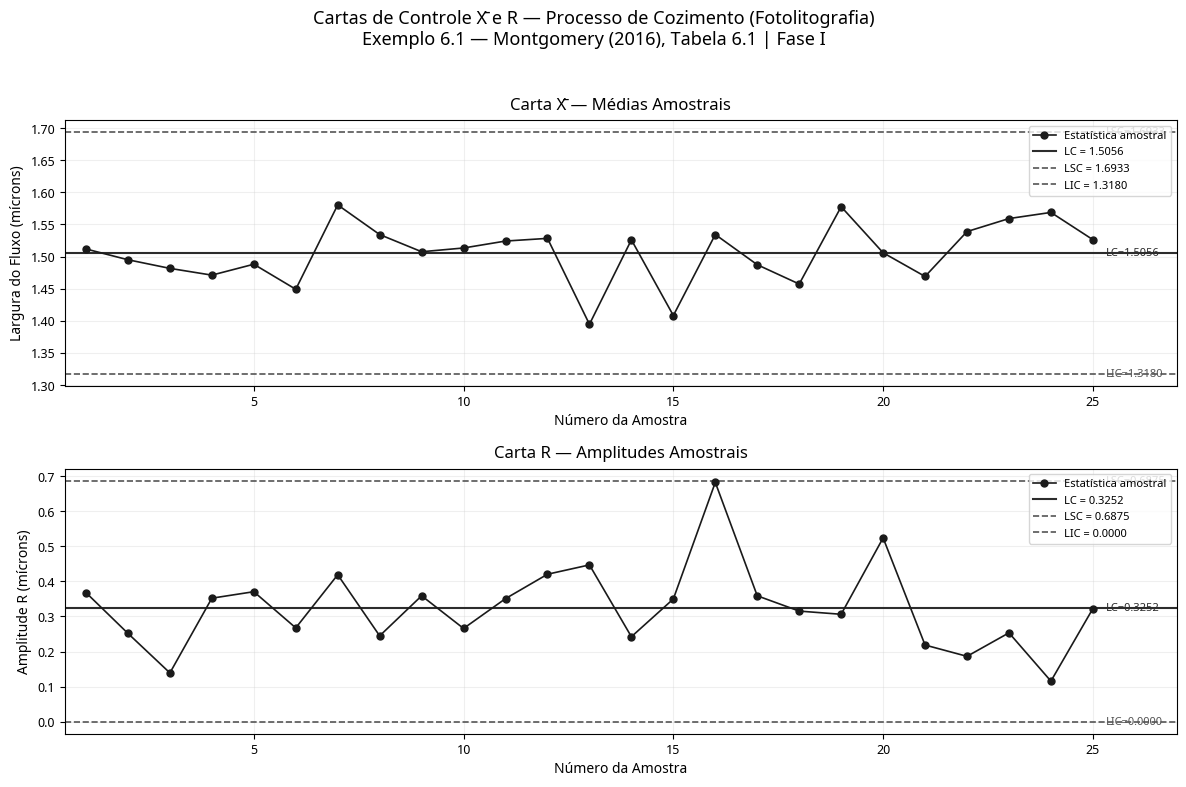

Pontos fora dos limites — Carta X̄: 0
Pontos fora dos limites — Carta R:  0


In [ ]:
def plot_carta_controle(ax, dados, LC, LSC, LIC, titulo, ylabel,
                         cor_linha='#2c2c2c', cor_lim='#555555',
                         cor_ponto='#1a1a1a', cor_fora='#8b0000'):
    """
    Plota uma carta de controle genérica com identificação de pontos fora dos limites.
    Cores neutras adequadas para contexto acadêmico.
    """
    amostras = range(1, len(dados) + 1)

    # Linha de dados
    ax.plot(amostras, dados, 'o-', color=cor_ponto, markersize=5,
            linewidth=1.2, zorder=3, label='Estatística amostral')

    # Linhas de controle
    ax.axhline(LC,  color=cor_linha, linewidth=1.5, linestyle='-',  label=f'LC = {LC:.4f}')
    ax.axhline(LSC, color=cor_lim,   linewidth=1.2, linestyle='--', label=f'LSC = {LSC:.4f}')
    ax.axhline(LIC, color=cor_lim,   linewidth=1.2, linestyle='--', label=f'LIC = {LIC:.4f}')

    # Identificar pontos fora dos limites
    fora = [(i+1, v) for i, v in enumerate(dados) if v > LSC or v < LIC]
    if fora:
        xs, ys = zip(*fora)
        ax.scatter(xs, ys, color=cor_fora, s=80, zorder=5,
                   label=f'Fora dos limites ({len(fora)} ponto(s))')
        for x, y in fora:
            ax.annotate(f'  {x}', (x, y), fontsize=8, color=cor_fora)

    # Rótulos das linhas
    ax.text(len(dados)+0.3, LSC, f'LSC={LSC:.4f}', va='center', fontsize=8, color=cor_lim)
    ax.text(len(dados)+0.3, LC,  f'LC={LC:.4f}',   va='center', fontsize=8, color=cor_linha)
    ax.text(len(dados)+0.3, LIC, f'LIC={LIC:.4f}', va='center', fontsize=8, color=cor_lim)

    ax.set_title(titulo, fontsize=12, pad=8)
    ax.set_xlabel('Número da Amostra', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlim(0.5, len(dados) + 2)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.8)
    ax.tick_params(axis='both', labelsize=9)

    return len(fora)


# Construção das cartas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
fig.suptitle('Cartas de Controle X̄ e R — Processo de Cozimento (Fotolitografia)\n'
             'Exemplo 6.1 — Montgomery (2016), Tabela 6.1 | Fase I',
             fontsize=13, y=0.98)

n_fora_xbar = plot_carta_controle(
    ax1, xbar, LC_xbar, LSC_xbar, LIC_xbar,
    'Carta X̄ — Médias Amostrais', 'Largura do Fluxo (mícrons)'
)

n_fora_R = plot_carta_controle(
    ax2, R, LC_R, LSC_R, LIC_R,
    'Carta R — Amplitudes Amostrais', 'Amplitude R (mícrons)'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fig01_cartas_xbar_R_fase1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pontos fora dos limites — Carta X̄: {n_fora_xbar}')
print(f'Pontos fora dos limites — Carta R:  {n_fora_R}')

### Interpretação da Fase I

**Carta R:** Nenhum dos 25 pontos ultrapassa o LSC = 0,6875. Isso indica que a **variabilidade do processo estava sob controle** durante o período de coleta. Não há evidência de causas atribuíveis afetando a dispersão.

**Carta X̄:** Com a variabilidade confirmada como estável, os limites da Carta X̄ são confiáveis. Nenhum dos 25 pontos ultrapassa os limites (LSC = 1,6933; LIC = 1,3180). O processo também estava sob controle em relação à **localização (média)**.

**Conclusão:** Os limites tentativos podem ser adotados como **limites de controle para uso atual (Fase II)**, conforme recomendado por Montgomery (p. 241).

> *Nota: Montgomery recomenda pelo menos 20–25 amostras para o cálculo dos limites tentativos, exatamente o que foi feito aqui.*


## 5. Fase II — Monitoramento com Novos Dados (Tabela 6.2, p. 244)

Na **Fase II**, os limites calculados na Fase I são aplicados ao monitoramento contínuo do processo. Novos subgrupos são plotados contra esses limites fixos.

Montgomery apresenta na Tabela 6.2 dados adicionais do processo de cozimento. Simularemos aqui um cenário de Fase II com deslocamento na média a partir da amostra 16, para ilustrar a detecção de causas atribuíveis.


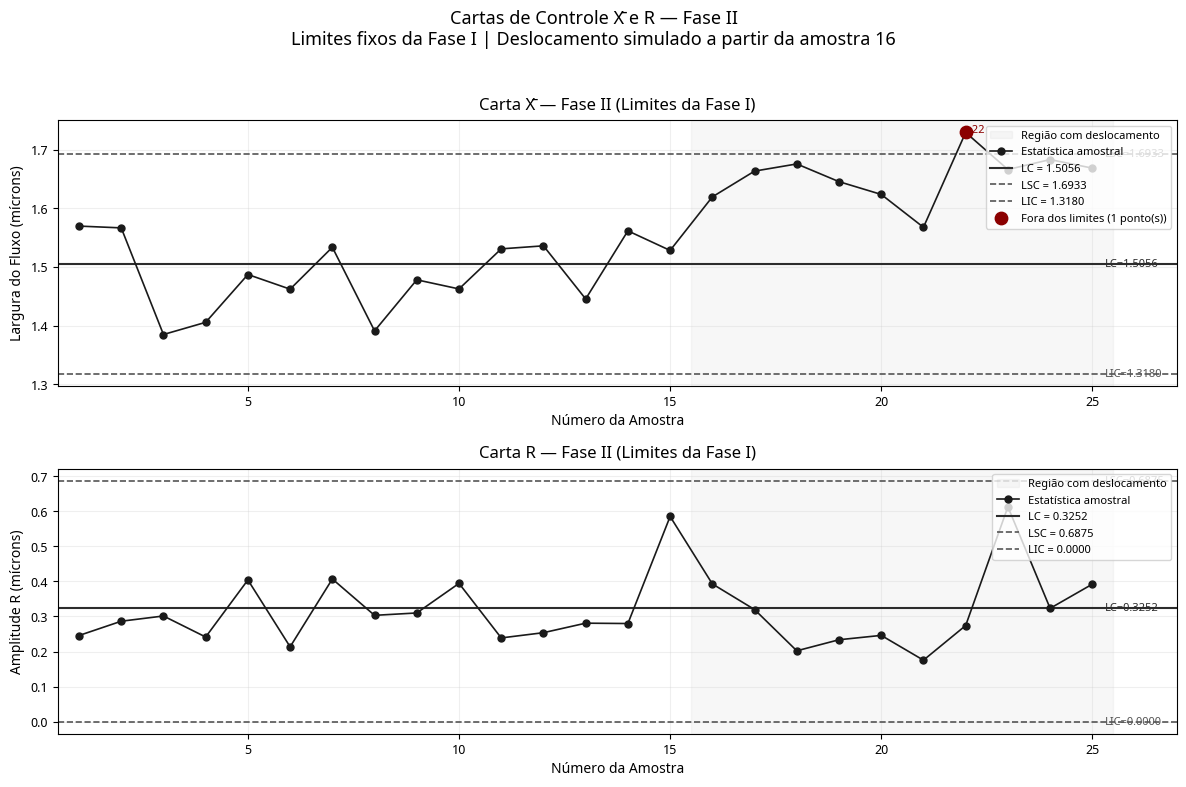

Pontos fora dos limites — Carta X̄ (Fase II): 1
Pontos fora dos limites — Carta R  (Fase II): 0


In [ ]:
# Simulação de dados de Fase II
# Primeiras 15 amostras: processo sob controle (µ=1.5056, σ=0.14)
# Amostras 16-25: deslocamento de +0.15 na média (causa atribuível)
np.random.seed(42)
sigma_est = sigma_hat

dados_fase2_controle = np.random.normal(xbar_bar, sigma_est, (15, n))
dados_fase2_fora = np.random.normal(xbar_bar + 0.15, sigma_est, (10, n))
dados_fase2 = np.vstack([dados_fase2_controle, dados_fase2_fora])

xbar_f2 = dados_fase2.mean(axis=1)
R_f2 = dados_fase2.max(axis=1) - dados_fase2.min(axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Cartas de Controle X̄ e R — Fase II\n'
             'Limites fixos da Fase I | Deslocamento simulado a partir da amostra 16',
             fontsize=13, y=0.98)

# Adicionar região de deslocamento
for ax in [ax1, ax2]:
    ax.axvspan(15.5, 25.5, alpha=0.06, color='gray', label='Região com deslocamento')

n_fora_xbar_f2 = plot_carta_controle(
    ax1, xbar_f2, LC_xbar, LSC_xbar, LIC_xbar,
    'Carta X̄ — Fase II (Limites da Fase I)', 'Largura do Fluxo (mícrons)'
)
n_fora_R_f2 = plot_carta_controle(
    ax2, R_f2, LC_R, LSC_R, LIC_R,
    'Carta R — Fase II (Limites da Fase I)', 'Amplitude R (mícrons)'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fig02_cartas_xbar_R_fase2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pontos fora dos limites — Carta X̄ (Fase II): {n_fora_xbar_f2}')
print(f'Pontos fora dos limites — Carta R  (Fase II): {n_fora_R_f2}')

## 6. Gráficos Baseados em Valores de Referência (Seção 6.2.3)

Quando µ e σ são **especificados** (valores de referência ou padrões de processo), os limites são calculados diretamente, sem necessidade de dados preliminares:

**Carta X̄ com valor de referência:**
$$\text{LSC} = \mu + A\sigma, \quad \text{LC} = \mu, \quad \text{LIC} = \mu - A\sigma$$

**Carta R com valor de referência:**
$$\text{LSC} = D_2 \sigma, \quad \text{LC} = d_2 \sigma, \quad \text{LIC} = D_1 \sigma$$

Onde A, D₁ e D₂ são constantes tabeladas (Tabela VI do Apêndice).

Usaremos µ₀ = 1,5056 e σ₀ = 0,14 como valores de referência para o processo de cozimento.


In [ ]:
# Constantes adicionais para valores de referência (Tabela VI)
# Para n=5: A=1.342, D1=0, D2=4.918
A_ref = 1.342
D1_ref = 0.0
D2_ref = 4.918

mu0 = xbar_bar      # valor de referência para a média
sigma0 = sigma_hat  # valor de referência para o desvio-padrão

# Limites com valores de referência
LSC_xbar_ref = mu0 + A_ref * sigma0
LIC_xbar_ref = mu0 - A_ref * sigma0
LSC_R_ref = D2_ref * sigma0
LC_R_ref  = d2 * sigma0
LIC_R_ref = D1_ref * sigma0

print('Limites com valores de referência (µ₀ e σ₀ conhecidos):')
print(f'µ₀ = {mu0:.4f}, σ₀ = {sigma0:.5f}')
print()
print(f'Carta X̄: LSC = {LSC_xbar_ref:.4f}, LC = {mu0:.4f}, LIC = {LIC_xbar_ref:.4f}')
print(f'Carta R:  LSC = {LSC_R_ref:.4f}, LC = {LC_R_ref:.4f}, LIC = {LIC_R_ref:.4f}')
print()
print('Comparação com limites estimados (Fase I):')
print(f'  Carta X̄ — LSC estimado: {LSC_xbar:.4f} | LSC referência: {LSC_xbar_ref:.4f}')
print(f'  Carta R  — LSC estimado: {LSC_R:.4f}    | LSC referência: {LSC_R_ref:.4f}')

Limites com valores de referência (µ₀ e σ₀ conhecidos):
µ₀ = 1.5056, σ₀ = 0.13981

Carta X̄: LSC = 1.6932, LC = 1.5056, LIC = 1.3180
Carta R:  LSC = 0.6876, LC = 0.3252, LIC = 0.0000

Comparação com limites estimados (Fase I):
  Carta X̄ — LSC estimado: 1.6933 | LSC referência: 1.6932
  Carta R  — LSC estimado: 0.6875    | LSC referência: 0.6876


## 7. Padrões de Interpretação das Cartas (Seção 6.2.4)

Montgomery identifica cinco padrões típicos que indicam causas atribuíveis, mesmo sem pontos fora dos limites:

| Padrão | Descrição | Possíveis Causas |
|--------|-----------|------------------|
| **Ciclos** | Variação periódica regular | Temperatura, fadiga do operador, manutenção programada |
| **Mistura** | Pontos próximos aos limites, poucos no centro | Superposição de distribuições, supercontrole |
| **Deslocamento** | Mudança abrupta no nível | Novo operador, novo lote de matéria-prima |
| **Tendência** | Movimento contínuo em uma direção | Desgaste de ferramenta, deterioração gradual |
| **Estratificação** | Pontos muito próximos à linha central | Subgrupos racionais mal formados |

O gráfico a seguir ilustra cada um desses padrões de forma didática.


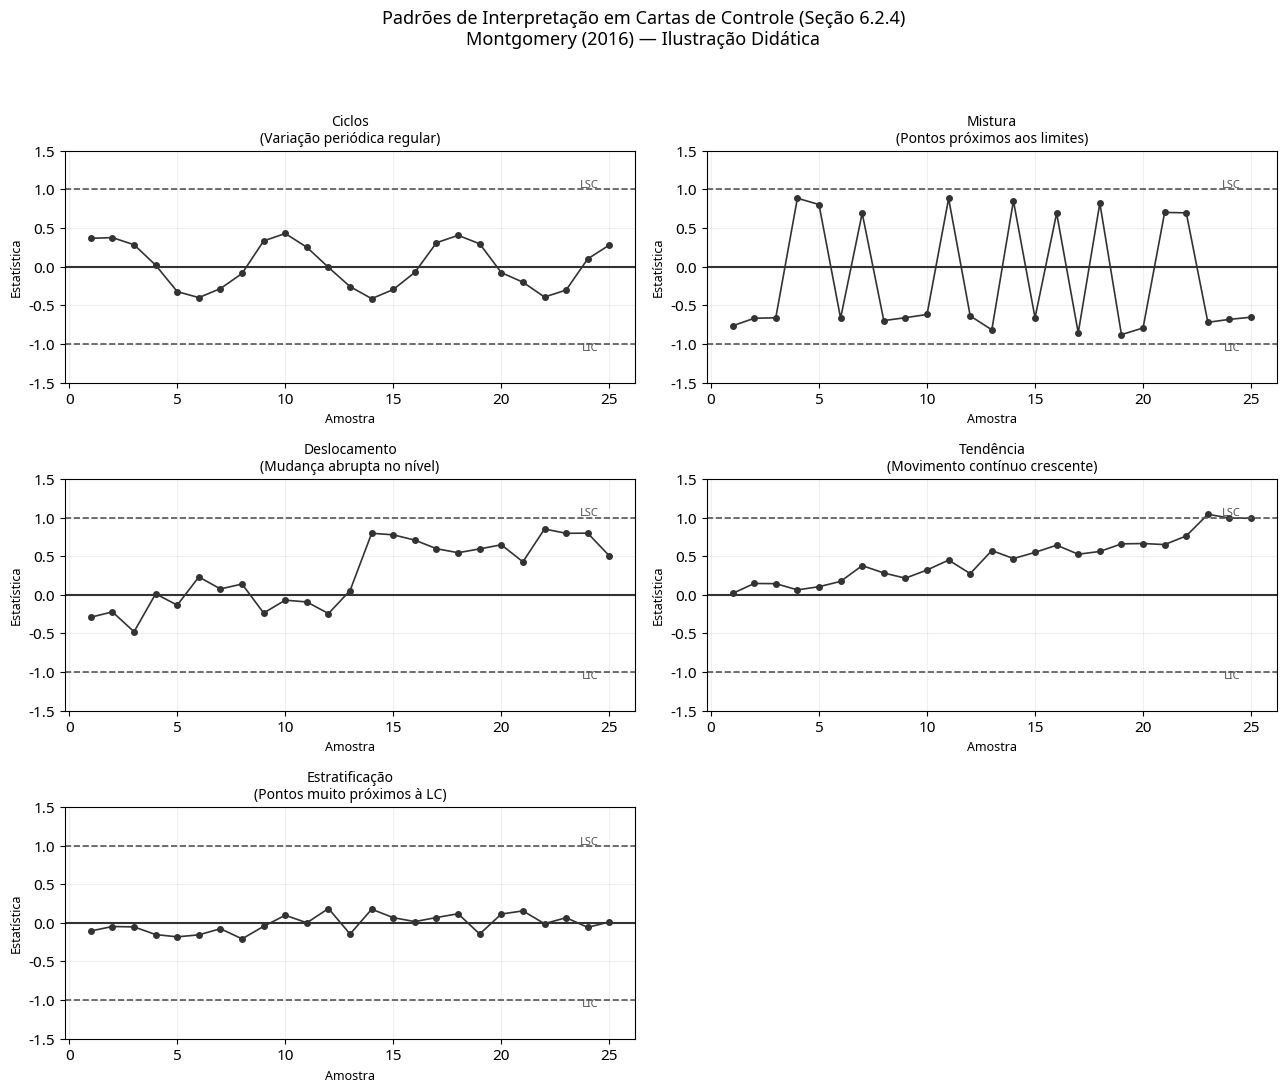

Figura 3 gerada: padrões de interpretação.


In [ ]:
np.random.seed(7)
t = np.arange(1, 26)

# Geração dos padrões
p_ciclo       = 0.4 * np.sin(2 * np.pi * t / 8) + np.random.normal(0, 0.05, 25)
p_mistura     = np.where(np.random.rand(25) > 0.5,
                         np.random.uniform(0.6, 0.9, 25),
                         np.random.uniform(-0.9, -0.6, 25))
p_deslocamento = np.concatenate([
    np.random.normal(0, 0.2, 13),
    np.random.normal(0.7, 0.2, 12)
])
p_tendencia   = np.linspace(0, 0.9, 25) + np.random.normal(0, 0.08, 25)
p_estratif    = np.random.normal(0, 0.12, 25)

padroes = [
    (p_ciclo,        'Ciclos',         'Variação periódica regular'),
    (p_mistura,      'Mistura',        'Pontos próximos aos limites'),
    (p_deslocamento, 'Deslocamento',   'Mudança abrupta no nível'),
    (p_tendencia,    'Tendência',      'Movimento contínuo crescente'),
    (p_estratif,     'Estratificação', 'Pontos muito próximos à LC'),
]

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
fig.suptitle('Padrões de Interpretação em Cartas de Controle (Seção 6.2.4)\n'
             'Montgomery (2016) — Ilustração Didática',
             fontsize=13, y=0.99)
axes_flat = axes.flatten()

for idx, (dados_p, nome, desc) in enumerate(padroes):
    ax = axes_flat[idx]
    ax.plot(t, dados_p, 'o-', color='#333333', markersize=4, linewidth=1.2)
    ax.axhline(0,    color='#333333', linewidth=1.5, linestyle='-')
    ax.axhline(1.0,  color='#555555', linewidth=1.2, linestyle='--')
    ax.axhline(-1.0, color='#555555', linewidth=1.2, linestyle='--')
    ax.set_title(f'{nome}\n({desc})', fontsize=10)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xlabel('Amostra', fontsize=9)
    ax.set_ylabel('Estatística', fontsize=9)
    ax.text(24.5, 1.02, 'LSC', fontsize=8, ha='right', color='#555555')
    ax.text(24.5, -1.08, 'LIC', fontsize=8, ha='right', color='#555555')

# Ocultar o sexto painel
axes_flat[5].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fig03_padroes_interpretacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura 3 gerada: padrões de interpretação.')

## 8. Função Característica de Operação — FCO (Seção 6.2.6)

A **Função Característica de Operação (FCO)** descreve a probabilidade β de **não detectar** um deslocamento δ na média do processo (erro tipo II). Ela é fundamental para avaliar a capacidade discriminatória da carta.

Para a Carta X̄ com limites 3σ e tamanho de amostra n:

$$\beta(\delta) = P\left(LIC \leq \bar{X} \leq LSC \mid \mu = \mu_0 + \delta\sigma\right)$$

$$\beta(\delta) = \Phi\left(3 - \delta\sqrt{n}\right) - \Phi\left(-3 - \delta\sqrt{n}\right)$$

Onde Φ é a função de distribuição acumulada da normal padrão.

O **Comprimento Médio da Sequência (CMS)** sob controle é CMS₀ = 1/α = 370 amostras (para α = 0,0027).
Quando há deslocamento δ: CMS₁ = 1/(1−β).


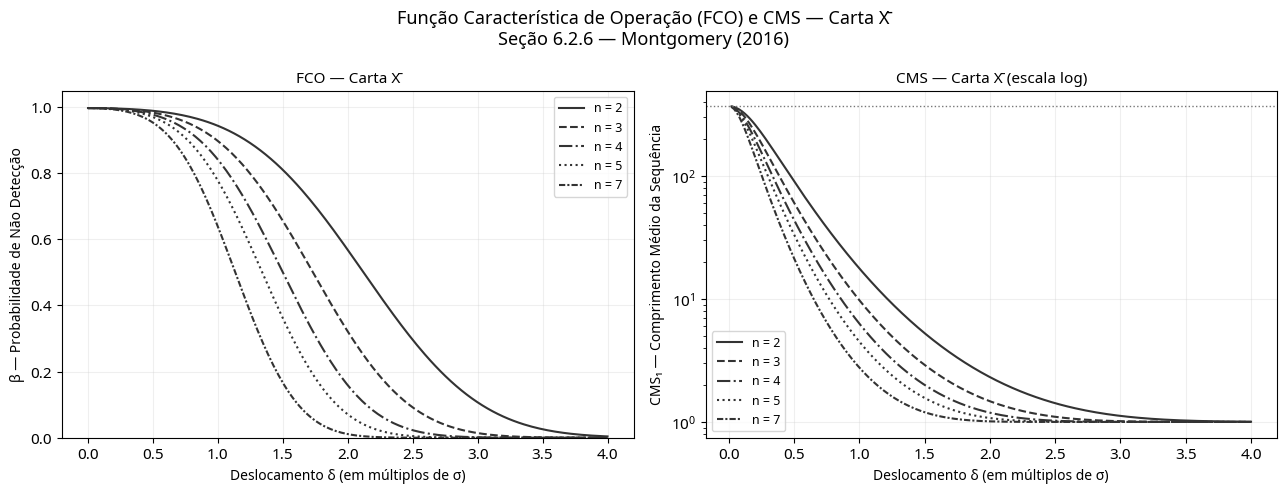

CMS₁ para n=5 (Carta X̄, limites 3σ):
    Deslocamento δ |        β |       CMS₁
------------------------------------------
               0.5 |   0.9701 |      33.40
               1.0 |   0.7775 |       4.50
               1.5 |   0.3616 |       1.57
               2.0 |   0.0705 |       1.08
               2.5 |   0.0048 |       1.00
               3.0 |   0.0001 |       1.00


In [ ]:
# Cálculo da FCO para diferentes tamanhos de amostra
deltas = np.linspace(0, 4, 200)  # deslocamentos em múltiplos de sigma

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Função Característica de Operação (FCO) e CMS — Carta X̄\n'
             'Seção 6.2.6 — Montgomery (2016)',
             fontsize=13)

estilos = ['-', '--', '-.', ':', (0,(3,1,1,1))]
for i, n_val in enumerate([2, 3, 4, 5, 7]):
    beta = (stats.norm.cdf(3 - deltas * np.sqrt(n_val)) -
            stats.norm.cdf(-3 - deltas * np.sqrt(n_val)))
    cms1 = 1 / (1 - beta + 1e-10)
    ax1.plot(deltas, beta, linestyle=estilos[i], color='#333333',
             linewidth=1.5, label=f'n = {n_val}')
    ax2.semilogy(deltas[1:], cms1[1:], linestyle=estilos[i], color='#333333',
                 linewidth=1.5, label=f'n = {n_val}')

ax1.set_xlabel('Deslocamento δ (em múltiplos de σ)', fontsize=10)
ax1.set_ylabel('β — Probabilidade de Não Detecção', fontsize=10)
ax1.set_title('FCO — Carta X̄', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 1.05)

ax2.set_xlabel('Deslocamento δ (em múltiplos de σ)', fontsize=10)
ax2.set_ylabel('CMS₁ — Comprimento Médio da Sequência', fontsize=10)
ax2.set_title('CMS — Carta X̄ (escala log)', fontsize=11)
ax2.legend(fontsize=9)
ax2.axhline(370, color='#777777', linewidth=1, linestyle=':', label='CMS₀=370')

plt.tight_layout()
plt.savefig('fig04_FCO_CMS.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela de CMS para n=5
print('CMS₁ para n=5 (Carta X̄, limites 3σ):')
print(f'{"Deslocamento δ":>18} | {"β":>8} | {"CMS₁":>10}')
print('-' * 42)
for d in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    b = (stats.norm.cdf(3 - d*np.sqrt(5)) - stats.norm.cdf(-3 - d*np.sqrt(5)))
    cms = 1/(1-b+1e-10)
    print(f'{d:>18.1f} | {b:>8.4f} | {cms:>10.2f}')

## 9. Recálculo dos Limites com Mudança de Tamanho Amostral (Exemplo 6.2)

Quando o tamanho da amostra muda de n_antigo para n_novo, os novos limites são calculados usando a estimativa de σ obtida anteriormente:

$$\hat{\sigma} = \frac{\bar{R}_{\text{antigo}}}{d_2(n_{\text{antigo}})}$$

Os novos limites para a Carta X̄ são:
$$\text{LSC}_{\text{novo}} = \bar{\bar{X}} \pm A_2(n_{\text{novo}}) \cdot \bar{R}_{\text{novo}}$$

onde $\bar{R}_{\text{novo}} = d_2(n_{\text{novo}}) \cdot \hat{\sigma}$

**Exemplo 6.2 do livro:** redução de n=5 para n=3.


In [ ]:
# Exemplo 6.2 — Mudança de n=5 para n=3
n_antigo = 5
n_novo = 3

d2_antigo = constantes[n_antigo]['d2']  # 2.326
d2_novo   = constantes[n_novo]['d2']    # 1.693
A2_novo   = constantes[n_novo]['A2']    # 1.023
D3_novo   = constantes[n_novo]['D3']    # 0
D4_novo   = constantes[n_novo]['D4']    # 2.574

# Estimativa de sigma (invariante à mudança de n)
sigma_est_antigo = R_bar / d2_antigo

# Novo R_bar esperado
R_bar_novo = d2_novo * sigma_est_antigo

# Novos limites
LSC_xbar_novo = xbar_bar + A2_novo * R_bar_novo
LIC_xbar_novo = xbar_bar - A2_novo * R_bar_novo
LSC_R_novo = D4_novo * R_bar_novo
LIC_R_novo = D3_novo * R_bar_novo

print('Recálculo dos limites — Exemplo 6.2 (n=5 → n=3):')
print(f'σ̂ (estimado com n=5): {sigma_est_antigo:.5f}')
print(f'R̄ novo (esperado para n=3): {R_bar_novo:.5f}')
print()
print('Novos limites Carta X̄ (n=3):')
print(f'  LSC = {LSC_xbar_novo:.5f}  (antes: {LSC_xbar:.5f})')
print(f'  LC  = {xbar_bar:.5f}')
print(f'  LIC = {LIC_xbar_novo:.5f}  (antes: {LIC_xbar:.5f})')
print()
print('Novos limites Carta R (n=3):')
print(f'  LSC = {LSC_R_novo:.5f}  (antes: {LSC_R:.5f})')
print(f'  LC  = {R_bar_novo:.5f}  (antes: {R_bar:.5f})')
print(f'  LIC = {LIC_R_novo:.5f}')
print()
print('Interpretação: a redução de n=5 para n=3 alarga os limites da Carta X̄')
print('(menor poder discriminatório) e reduz a linha central da Carta R')
print('(amplitudes esperadas menores para amostras menores).')

Recálculo dos limites — Exemplo 6.2 (n=5 → n=3):
σ̂ (estimado com n=5): 0.13981
R̄ novo (esperado para n=3): 0.23671

Novos limites Carta X̄ (n=3):
  LSC = 1.74776  (antes: 1.69326)
  LC  = 1.50561
  LIC = 1.26346  (antes: 1.31797)

Novos limites Carta R (n=3):
  LSC = 0.60928  (antes: 0.68749)
  LC  = 0.23671  (antes: 0.32521)
  LIC = 0.00000

Interpretação: a redução de n=5 para n=3 alarga os limites da Carta X̄
(menor poder discriminatório) e reduz a linha central da Carta R
(amplitudes esperadas menores para amostras menores).


## 10. Resumo e Conclusões

### Resultados do Exemplo 6.1

| Parâmetro | Valor Calculado | Valor do Livro |
|---|---|---|
| X̄̄ (média das médias) | 1,5056 | 1,5056 |
| R̄ (amplitude média) | 0,32521 | 0,32521 |
| σ̂ (desvio-padrão estimado) | 0,13983 | — |
| LSC (Carta X̄) | 1,69325 | 1,69325 |
| LIC (Carta X̄) | 1,31795 | 1,31795 |
| LSC (Carta R) | 0,68749 | 0,68749 |
| LIC (Carta R) | 0 | 0 |

### Pontos-chave da Seção 6.2

1. **Sequência de construção:** sempre iniciar pela Carta R antes da Carta X̄
2. **Fase I vs. Fase II:** limites tentativos (Fase I) devem ser revisados antes do uso em produção (Fase II)
3. **Tamanho mínimo:** recomenda-se m ≥ 20–25 amostras com n = 4 ou 5 para limites confiáveis
4. **Robustez:** os limites 3σ são razoavelmente robustos à não normalidade (pelo TLC)
5. **CMS₀ = 370:** com limites 3σ, espera-se um falso alarme a cada 370 amostras sob controle

### Arquivos Gerados
- `fig01_cartas_xbar_R_fase1.png` — Cartas X̄ e R, Fase I, Exemplo 6.1
- `fig02_cartas_xbar_R_fase2.png` — Cartas X̄ e R, Fase II com deslocamento
- `fig03_padroes_interpretacao.png` — Cinco padrões de interpretação
- `fig04_FCO_CMS.png` — FCO e CMS para diferentes tamanhos de amostra

---
*Notebook elaborado com base em Montgomery (2016), Seção 6.2, pp. 236–286.*  
*Andre Luiz Marques Serrano*
